<a href="https://colab.research.google.com/github/DeeptiYadav10648/2415800029-computer-programming/blob/main/GNN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import torch
print("PyTorch has version {}".format(torch.__version__))

PyTorch has version 2.11.0+cpu


In [32]:
# Install torch geometric
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.4.0+cu121.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.4.0+cu121.html
!pip install -q torch-geometric

VISUALIZATION

In [33]:
# Helper function for visualization.
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None, accuracy=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None and accuracy['train'] is not None and accuracy['val'] is not None:
            plt.xlabel((f'Epoch: {epoch}, Loss: {loss.item():.4f} \n'
                       f'Training Accuracy: {accuracy["train"]*100:.2f}% \n'
                       f' Validation Accuracy: {accuracy["val"]*100:.2f}%'),
                       fontsize=16)
    else:
        nx.draw_networkx(h, pos=nx.spring_layout(h, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()

## Dataset

PyTorch Geometric provides an easy access to the dataset via the [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) subpackage:

In [34]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [35]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {(data.num_edges) / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Contains isolated nodes: {data.has_isolated_nodes()}')
print(f'Contains self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


From above , we can see that Data object holds 4 attributes (edge_index , node features as x , node labels as y and train_mask).

`x` (Node Features):
The x attribute contains the information or features of each node in the graph. In the Karate Club dataset, there are 34 members, and each member is represented by a unique feature vector. You can think of x as the initial information available about every node before the GNN starts learning. These features help the model identify and differentiate between nodes.

`edge_index` (Graph Connections):
The edge_index attribute shows how the nodes are connected to each other. In the Karate Club dataset, an edge represents a friendship between two club members. This attribute acts like a map of the network, telling the GNN which nodes are neighbors and can share information during the learning process.

`y` (Node Labels):
The y attribute stores the correct class or group for each node. In the Karate Club dataset, the club eventually split into two groups, and each member belongs to one of these groups. These labels are the answers that the GNN tries to learn and predict.

`train_mask` (Training Mask):
The train_mask attribute tells the model which nodes should be used for training. A value of True means the node's label is known and can be used to teach the model, while False means the node is not used during training. This helps the GNN learn from a few labeled nodes and then predict the groups of the remaining nodes.

In [36]:
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


EDGE INDEX

In [37]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

edge_index = data.edge_index
print(edge_index.t())
#Printing edge_index.t() allows us to directly see all the relationships in the graph

<IPython.core.display.Javascript object>

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

The first two lines use JavaScript in Google Colab to limit the height of the output cell. Since the Karate Club dataset contains many edges, the output can become very long. Restricting the height makes the notebook cleaner and easier to read.

`edge_index` = data.edge_index stores the graph connectivity information in the variable edge_index.

`print(edge_index.t())` prints the transpose of edge_index. By default, `edge_index` has a shape of [2, Number of Edges], where:

Row 1 contains source nodes.
Row 2 contains destination nodes.

After transposing (.t()), each row represents a single edge in the graph



**Example**

If the output contains:

`tensor([
    [0, 1],
    [0, 2],
    [1, 0],
    [2, 0]
])`

It means:

Node 0 is connected to Node 1

Node 0 is connected to Node 2

Node 1 is connected to Node 0

Node 2 is connected to Node 0

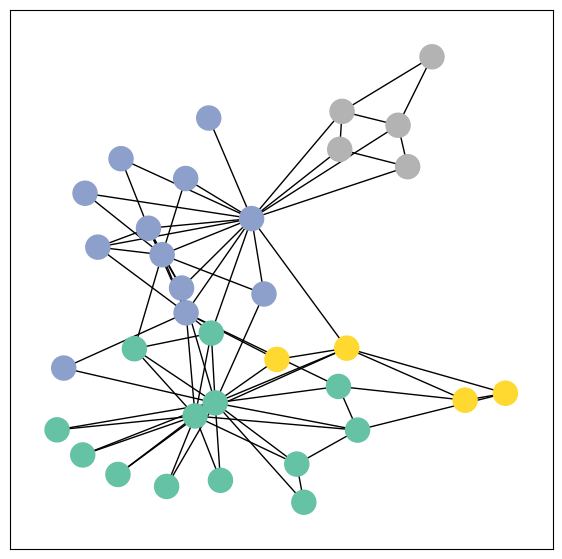

In [38]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)

`to_networkx()` converts the PyTorch Geometric graph into a NetworkX graph.

`to_undirected =True` treats friendships as two-way connections.
visualize() draws the graph.

`color=data.y` colors nodes according to their class labels.

The resulting visualization helps us observe the social structure and communities present in the Karate Club network before applying a GNN.

# **Implementing a Graph Neural Network (GNN)**

After exploring and visualizing the Karate Club graph, we will now implement a Graph Neural Network (GNN). The goal is to classify each club member into one of the two groups formed after the club split.

A GNN learns from both:

`Node features (x)` – information about each node.

`Graph structure (edge_index)` – how nodes are connected.

Unlike traditional neural networks, a GNN allows nodes to exchange information with their neighbors through a process called message passing. During this process, each node gathers information from its connected neighbors, combines it with its own features, and learns a new representation called a node embedding.

In [39]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes) ##a fully connected (linear) layer is used to convert the 2-dimensional embeddings into class scores.
        #the GCNConv layers reduce the node feature dimensionality to  2 , i.e.,  34→4→4→2 .

    def forward(self, x, edge_index):    #The forward() function defines how data moves through the network.
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.     #tanh is aan activation function adding non linearity to the graph and ranging values between -1 and 1 . It helps the model to learn the complex pattern in the graph.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h  #out → Predicted class scores for each node. ; h → Learned node embeddings.

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


# Model Architeccture Summary

Input Features (34)

        ↓
GCNConv(34 → 4)

        ↓
Tanh

        ↓
GCNConv(4 → 4)

        ↓
Tanh

        ↓
GCNConv(4 → 2)

        ↓
Tanh

        ↓
Node Embeddings (2D)

        ↓
Linear Classifier

        ↓
Predicted Classes

Embedding shape: [34, 2]


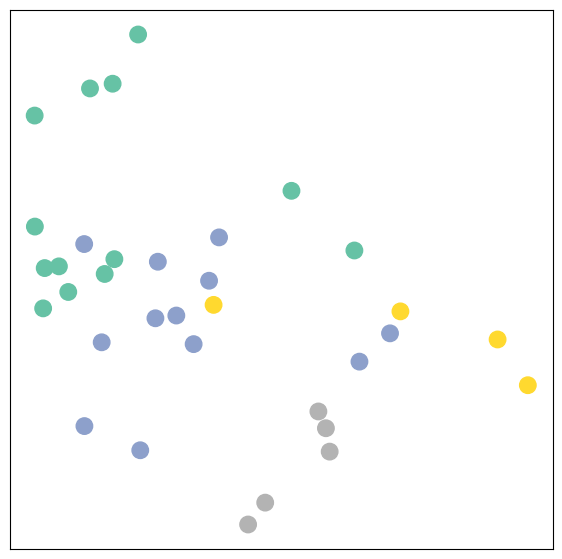

In [40]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y)

Training Setup

Define loss and optimizer

In [41]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

CrossEntropyLoss is used for node classification.

Adam is used to optimize the model parameters.

The learning rate (lr=0.01) controls how much the weights change during each update.

Create training function

In [42]:
def train():
    optimizer.zero_grad()  #clears old gradient .

    out, h = model(data.x, data.edge_index)  #model() performs a forward pass .

    loss = criterion(out[data.train_mask],
                     data.y[data.train_mask])  ## Compute the loss solely based on the training nodes.

    loss.backward() #Derive gradients
    optimizer.step() # Update parameters based on gradients .

    return loss, h

Train the GNN

In [43]:
for epoch in range(401):
    loss, h = train()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 000 | Loss: 1.4324
Epoch 020 | Loss: 1.2063
Epoch 040 | Loss: 0.7593
Epoch 060 | Loss: 0.4161
Epoch 080 | Loss: 0.2548
Epoch 100 | Loss: 0.1795
Epoch 120 | Loss: 0.1373
Epoch 140 | Loss: 0.1102
Epoch 160 | Loss: 0.0913
Epoch 180 | Loss: 0.0773
Epoch 200 | Loss: 0.0667
Epoch 220 | Loss: 0.0583
Epoch 240 | Loss: 0.0515
Epoch 260 | Loss: 0.0459
Epoch 280 | Loss: 0.0413
Epoch 300 | Loss: 0.0374
Epoch 320 | Loss: 0.0341
Epoch 340 | Loss: 0.0312
Epoch 360 | Loss: 0.0287
Epoch 380 | Loss: 0.0265
Epoch 400 | Loss: 0.0246


Visualize Learned Embeddings

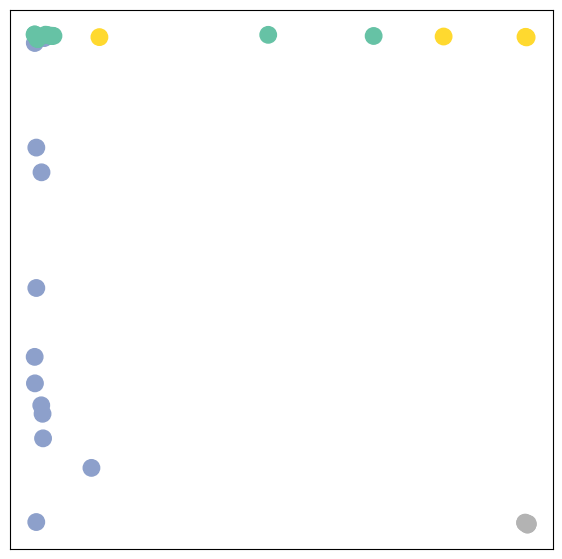

In [44]:
model.eval()

out, h = model(data.x, data.edge_index)

visualize(h, color=data.y)

Predict Node Classes

In [45]:
pred = out.argmax(dim=1)

print(pred)

tensor([1, 1, 0, 1, 3, 3, 3, 1, 0, 0, 3, 1, 1, 0, 0, 0, 3, 1, 0, 0, 0, 1, 0, 0,
        2, 2, 0, 2, 0, 0, 0, 2, 0, 0])


Compute Accuracy

In [46]:
correct = pred == data.y

acc = int(correct.sum()) / len(data.y)
Loss = loss.item()

print(f"Accuracy: {acc:.4f}")
print(f"Loss: {Loss:.4f}")

Accuracy: 0.8235
Loss: 0.0246


Visualize how embeddings evolve during training:

Epoch: 000 | Loss: 0.0245 | Accuracy: 0.8235


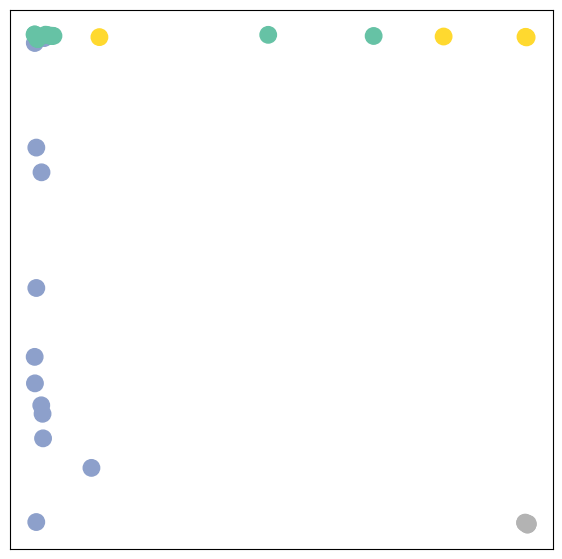

Epoch: 010 | Loss: 0.0236 | Accuracy: 0.8235
Epoch: 020 | Loss: 0.0228 | Accuracy: 0.8235
Epoch: 030 | Loss: 0.0220 | Accuracy: 0.8235
Epoch: 040 | Loss: 0.0213 | Accuracy: 0.8235
Epoch: 050 | Loss: 0.0206 | Accuracy: 0.8235


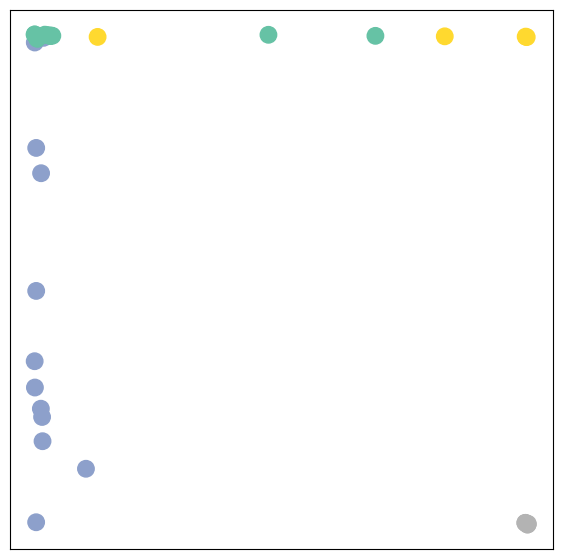

Epoch: 060 | Loss: 0.0199 | Accuracy: 0.8235
Epoch: 070 | Loss: 0.0193 | Accuracy: 0.8235
Epoch: 080 | Loss: 0.0187 | Accuracy: 0.8235
Epoch: 090 | Loss: 0.0181 | Accuracy: 0.8235
Epoch: 100 | Loss: 0.0175 | Accuracy: 0.8235


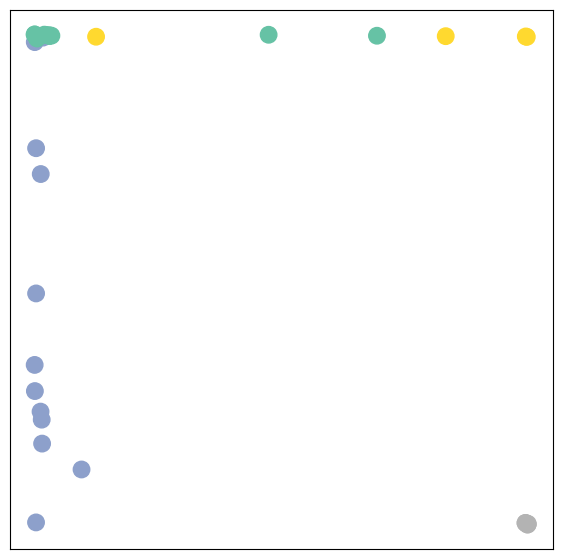

Epoch: 110 | Loss: 0.0170 | Accuracy: 0.8235
Epoch: 120 | Loss: 0.0165 | Accuracy: 0.8235
Epoch: 130 | Loss: 0.0161 | Accuracy: 0.8235
Epoch: 140 | Loss: 0.0156 | Accuracy: 0.8235
Epoch: 150 | Loss: 0.0152 | Accuracy: 0.8235


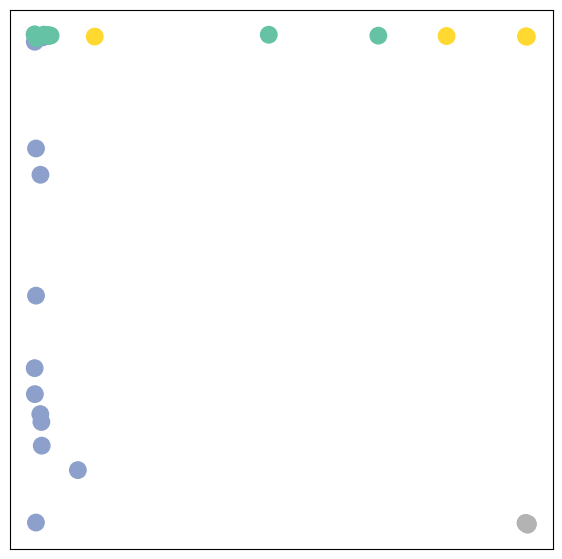

Epoch: 160 | Loss: 0.0148 | Accuracy: 0.8235
Epoch: 170 | Loss: 0.0144 | Accuracy: 0.8235
Epoch: 180 | Loss: 0.0140 | Accuracy: 0.8235
Epoch: 190 | Loss: 0.0136 | Accuracy: 0.8235
Epoch: 200 | Loss: 0.0133 | Accuracy: 0.8235


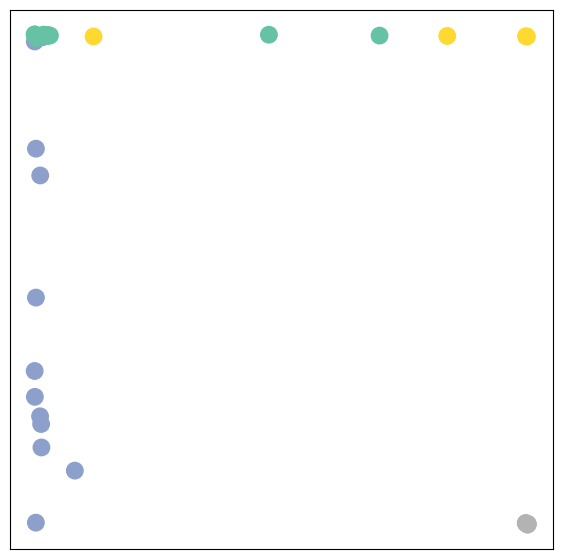

Epoch: 210 | Loss: 0.0130 | Accuracy: 0.8235
Epoch: 220 | Loss: 0.0126 | Accuracy: 0.8235
Epoch: 230 | Loss: 0.0123 | Accuracy: 0.8235
Epoch: 240 | Loss: 0.0120 | Accuracy: 0.8235
Epoch: 250 | Loss: 0.0118 | Accuracy: 0.8235


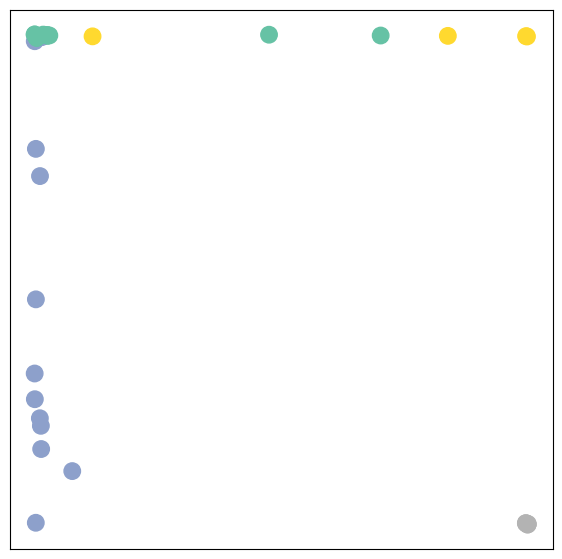

Epoch: 260 | Loss: 0.0115 | Accuracy: 0.8235
Epoch: 270 | Loss: 0.0112 | Accuracy: 0.8235
Epoch: 280 | Loss: 0.0110 | Accuracy: 0.8235
Epoch: 290 | Loss: 0.0107 | Accuracy: 0.8235
Epoch: 300 | Loss: 0.0105 | Accuracy: 0.8235


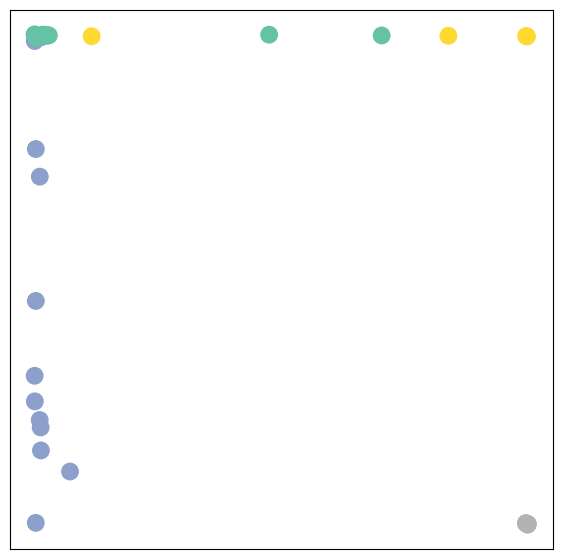

Epoch: 310 | Loss: 0.0103 | Accuracy: 0.8235
Epoch: 320 | Loss: 0.0100 | Accuracy: 0.8235
Epoch: 330 | Loss: 0.0098 | Accuracy: 0.8235
Epoch: 340 | Loss: 0.0096 | Accuracy: 0.8235
Epoch: 350 | Loss: 0.0094 | Accuracy: 0.8235


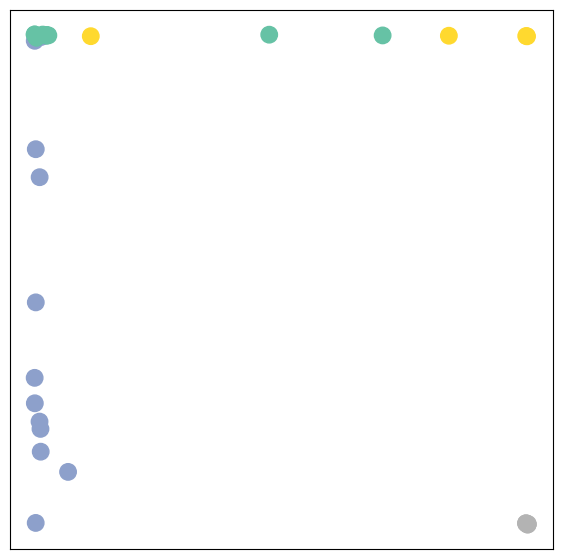

Epoch: 360 | Loss: 0.0092 | Accuracy: 0.8235
Epoch: 370 | Loss: 0.0090 | Accuracy: 0.8235
Epoch: 380 | Loss: 0.0088 | Accuracy: 0.8235
Epoch: 390 | Loss: 0.0087 | Accuracy: 0.8235
Epoch: 400 | Loss: 0.0085 | Accuracy: 0.8235


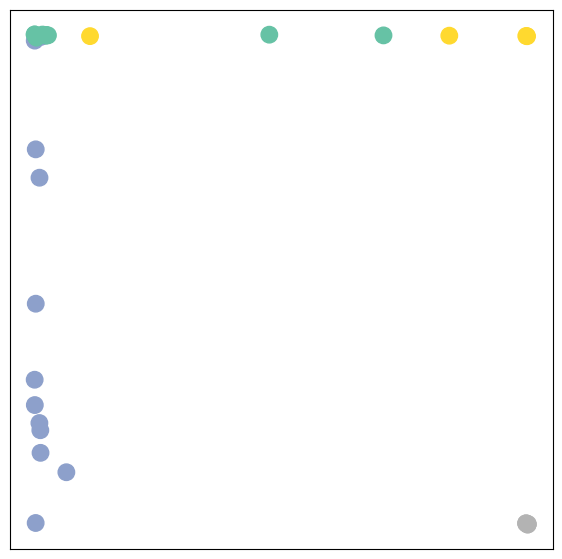

In [47]:
for epoch in range(401):
    loss, h = train()

    model.eval()
    out, _ = model(data.x, data.edge_index)

    pred = out.argmax(dim=1)

    correct = pred == data.y
    acc = correct.sum().item() / len(data.y)

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {acc:.4f}"
        )

    if epoch % 50 == 0:
        visualize(h, color=data.y)